In [1]:
!pip install matplotlib

In [4]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

Device = torch.device('cuda:0')

@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr
):
  pid = tl.program_id(axis=0)
  block_start = pid * BLOCK_SIZE
  offsets = block_start + tl.arange(0, BLOCK_SIZE)
  mask = offsets < n_elements

  #loading data from DRAM to SRAM
  x = tl.load(x_ptr + offsets, mask=mask, other=None)
  y = tl.load(y_ptr + offsets, mask=mask, other=None)
  output = x + y

  #loading data from SRAM to DRAM
  tl.store(output_ptr + offsets, output, mask=mask)

def add(x, y):
  output = torch.empty_like(x)

  assert x.device == Device and y.device == Device

  n_elements = output.numel()
  grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)

  add_kernel[grid](
        x,
        y,
        output,
        n_elements,
        BLOCK_SIZE=1024
    )

  return output

def test_add_kernel(size, atol=1e-3, rtol=1e-3, device=Device):
  torch.manual_seed(0)
  x = torch.rand(size, device=device)
  y = torch.rand(size, device=device)

  z_tri = add(x, y)
  z_ref = x + y

  torch.testing.assert_close(z_tri, z_ref, atol=atol, rtol=rtol)
  print("passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'], # argument names to use as an x-axis for the plot
        x_vals=[2**i for i in range(12, 25, 1)], # different values of x_names to benchmark
        x_log = True, # makes x-axis logarithmic
        line_arg='provider', # title of the legend
        line_vals=['triton', 'torch'], # designators of the different entries in the legend
        line_names=['Triton', 'Torch'], # names to visibly go in the legend
        styles=[('red', '-'), ('blue', '-')], # triton will be blue; pytorch will be green
        ylabel='GB/s', # label name for y-axis
        plot_name='vector-add-performance', # also used as file name for saving plot
        args={}, # we'll see how this is used in a later tutorial; need it even if it's empty
    )
)
def benchmark(size, provider):
    # creating our input data
    x = torch.rand(size, device=Device, dtype=torch.float32)
    y = torch.rand(size, device=Device, dtype=torch.float32)
    # each benchmark runs multiple times and quantiles tells matplotlib what confidence intervals to plot
    quantiles = [0.5, 0.05, 0.95]
    # defining which function this benchmark instance runs
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    # turning the raw millisecond measurement into meaninful units
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        # 3 = number of memory operations (2 reads + 1 write)
        # x.numel() = number of elements
        # x.element_size() = bytes per element (4 for float32, 2 for float16)
        # 1e-9 converts bytes to GB
        # 1e-3 converts milliseconds to seconds
    return gbps(ms), gbps(max_ms), gbps(min_ms)


passed
passed


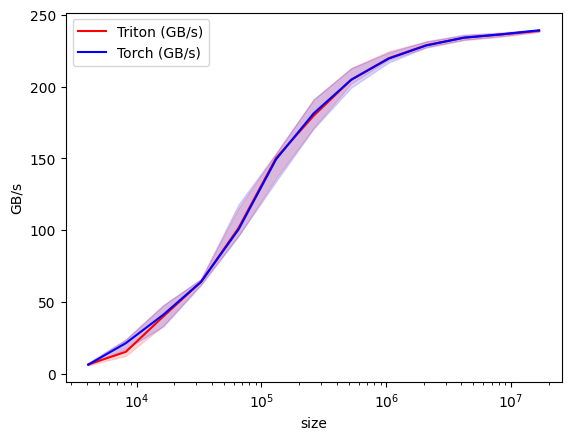

vector-add-performance:
          size  Triton (GB/s)  Torch (GB/s)
0       4096.0       6.592275      6.426778
1       8192.0      15.360000     21.407665
2      16384.0      40.026059     41.234899
3      32768.0      63.999998     63.999998
4      65536.0     101.553721    100.515338
5     131072.0     150.311933    149.398175
6     262144.0     179.714817    181.372696
7     524288.0     204.800005    204.800005
8    1048576.0     219.796534    219.551087
9    2097152.0     228.880087    228.680423
10   4194304.0     234.057145    234.057145
11   8388608.0     236.307695    236.432018
12  16777216.0     238.828378    239.182490


In [5]:
test_add_kernel(4096)
test_add_kernel(4097)

benchmark.run(show_plots=True, print_data=True)